<a href="https://colab.research.google.com/github/Ahmed0607/OncoVision-AI/blob/main/OncoVision_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
!pip install -q xgboost seaborn scikit-learn optuna shap

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score

import xgboost as xgb

sns.set_theme(style="darkgrid", palette="pastel")

In [33]:
df = pd.read_csv(r"Cancer_Data.csv")

df['target'] = df['diagnosis'].map({'M': 0, 'B': 1})

columns_to_drop = ['id', 'diagnosis','Unnamed: 32']

df_clean = df.drop(columns=columns_to_drop, axis=1)

print("Cleaned Dataset Shape:", df_clean.shape)
print("\nClass Distribution:")
print(df_clean['target'].value_counts(normalize=True))

df_clean.tail()

Cleaned Dataset Shape: (569, 31)

Class Distribution:
target
1    0.627417
0    0.372583
Name: proportion, dtype: float64


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,target
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,0
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,0
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,0
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,0
568,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,0.1587,0.05884,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,1


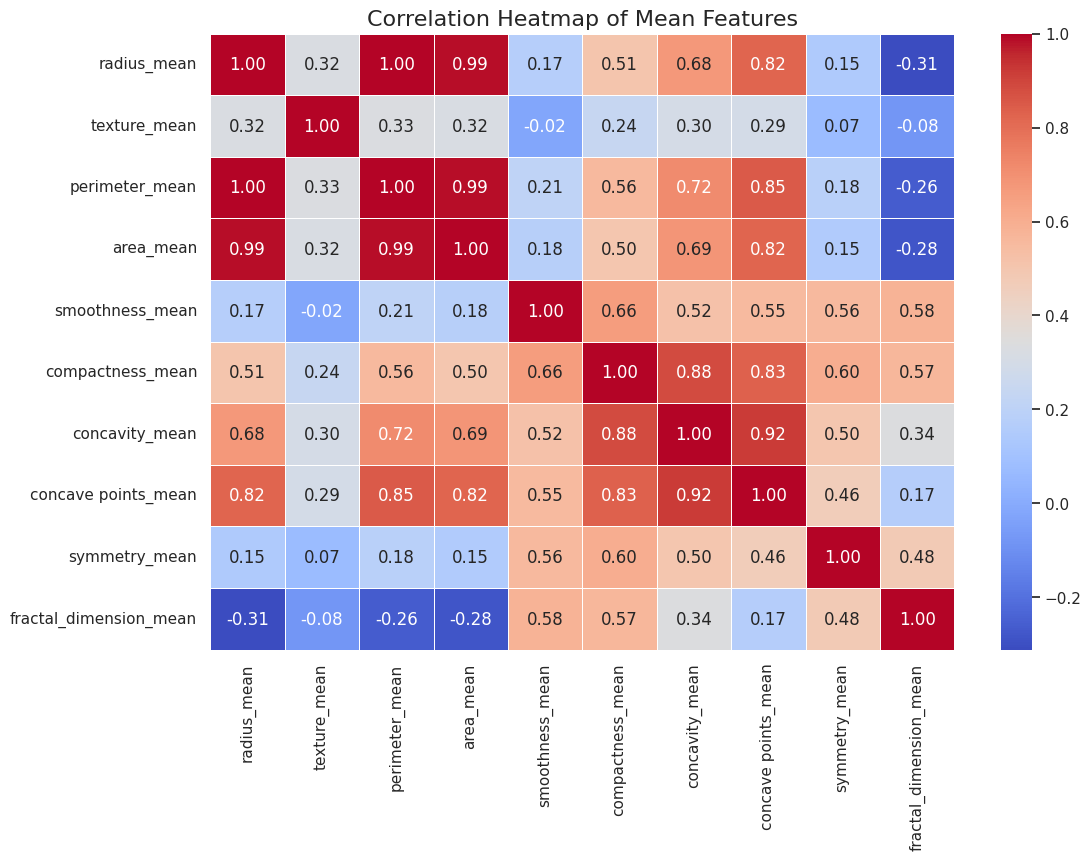

In [34]:
plt.figure(figsize=(12, 8))
selected_features = df_clean.columns[:10]
correlation_matrix = df_clean[selected_features].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Mean Features", fontsize=16)
plt.show()

In [35]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (455, 30)
Testing data shape: (114, 30)


In [36]:
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', random_state=42)

param_distributions = {
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 6, 8],
    'min_child_weight': [1, 3, 5],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'n_estimators': [100, 200, 300]
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_distributions,
    n_iter=25,          # Number of parameter settings to sample
    scoring='roc_auc',  # Optimizing for ROC-AUC
    cv=cv_strategy,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

print("Starting Hyperparameter Tuning...")
random_search.fit(X_train_scaled, y_train)

print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest Cross-Validation ROC-AUC Score: {random_search.best_score_:.4f}")

best_xgb_model = random_search.best_estimator_

Starting Hyperparameter Tuning...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters Found:
{'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

Best Cross-Validation ROC-AUC Score: 0.9950


--- Model Evaluation on Test Set ---
Accuracy: 0.9561
ROC-AUC Score: 0.9927

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



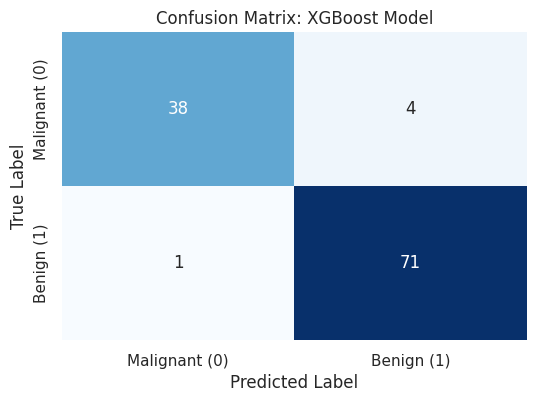

In [37]:
y_pred = best_xgb_model.predict(X_test_scaled)
y_pred_proba = best_xgb_model.predict_proba(X_test_scaled)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("--- Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Malignant (0)', 'Benign (1)'],
            yticklabels=['Malignant (0)', 'Benign (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: XGBoost Model')
plt.show()

In [38]:
import optuna
from sklearn.model_selection import cross_val_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'random_state': 42,
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 7),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'alpha': trial.suggest_float('alpha', 1e-8, 1.0, log=True),
        'lambda': trial.suggest_float('lambda', 1e-8, 1.0, log=True)
    }

    optuna_xgb = xgb.XGBClassifier(**param)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        optuna_xgb,
        X_train_scaled,
        y_train,
        cv=cv,
        scoring='roc_auc',
        n_jobs=-1
    )

    return scores.mean()

print("Starting Optuna Optimization Study...")

study = optuna.create_study(direction='maximize', study_name="XGBoost_Cancer_Optimization")
study.optimize(objective, n_trials=50, show_progress_bar=True)

print("\n--- Optuna Tuning Results ---")
print(f"Best ROC-AUC Score: {study.best_value:.4f}")
print("Best Hyperparameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

best_optuna_params = study.best_params
best_optuna_params['objective'] = 'binary:logistic'
best_optuna_params['eval_metric'] = 'logloss'
best_optuna_params['random_state'] = 42

final_optuna_model = xgb.XGBClassifier(**best_optuna_params)
final_optuna_model.fit(X_train_scaled, y_train)

y_pred = final_optuna_model.predict(X_test_scaled)
y_pred_proba = final_optuna_model.predict_proba(X_test_scaled)[:, 1]

print("\nFinal optimized model successfully trained!")

Starting Optuna Optimization Study...


  0%|          | 0/50 [00:00<?, ?it/s]


--- Optuna Tuning Results ---
Best ROC-AUC Score: 0.9946
Best Hyperparameters:
  max_depth: 5
  min_child_weight: 1
  learning_rate: 0.18996040012750445
  n_estimators: 214
  subsample: 0.7859229310039769
  colsample_bytree: 0.5574866559728618
  alpha: 0.0643436796795217
  lambda: 5.835247469784917e-07

Final optimized model successfully trained!


In [39]:
accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("--- Final Model Evaluation on Test Set ---")
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}\n")

--- Final Model Evaluation on Test Set ---
Accuracy: 0.9474
ROC-AUC Score: 0.9921



In [40]:
import shap

shap.initjs()

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

explainer = shap.TreeExplainer(best_xgb_model)

shap_values = explainer.shap_values(X_test_scaled_df)

print("SHAP values calculated successfully!")

SHAP values calculated successfully!


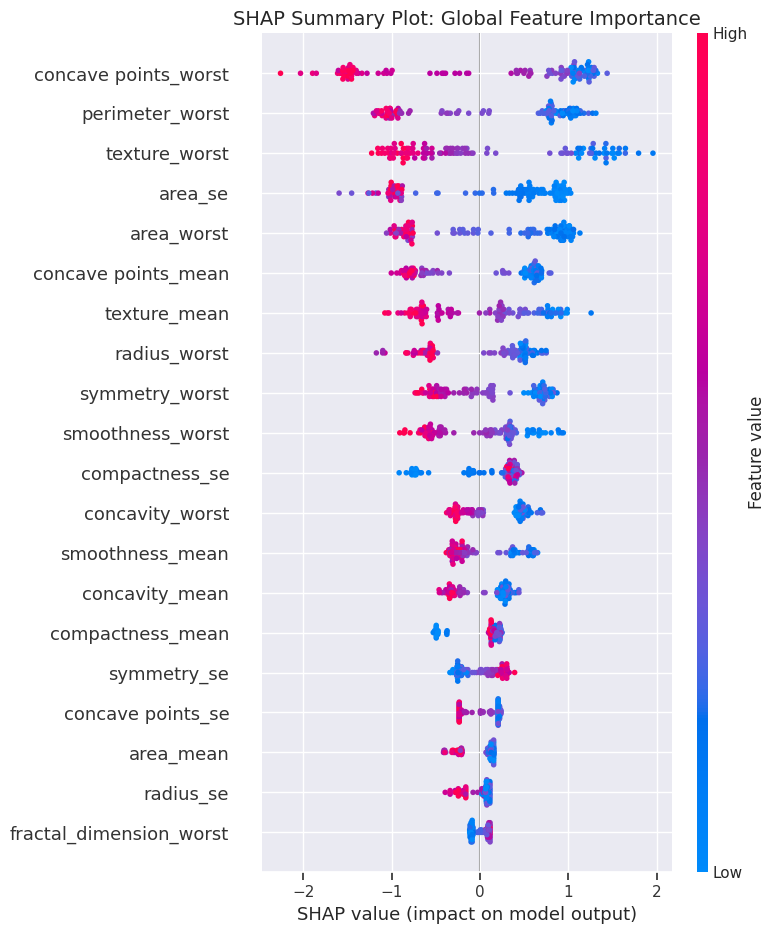

In [41]:
plt.figure(figsize=(10, 8))
plt.title("SHAP Summary Plot: Global Feature Importance", fontsize=14)

shap.summary_plot(shap_values, X_test_scaled_df, show=False)

plt.tight_layout()
plt.show()

Explaining prediction for Patient Index: 0
Actual Diagnosis: Malignant (0)
Model Predicted Probability of being Benign: 0.0006


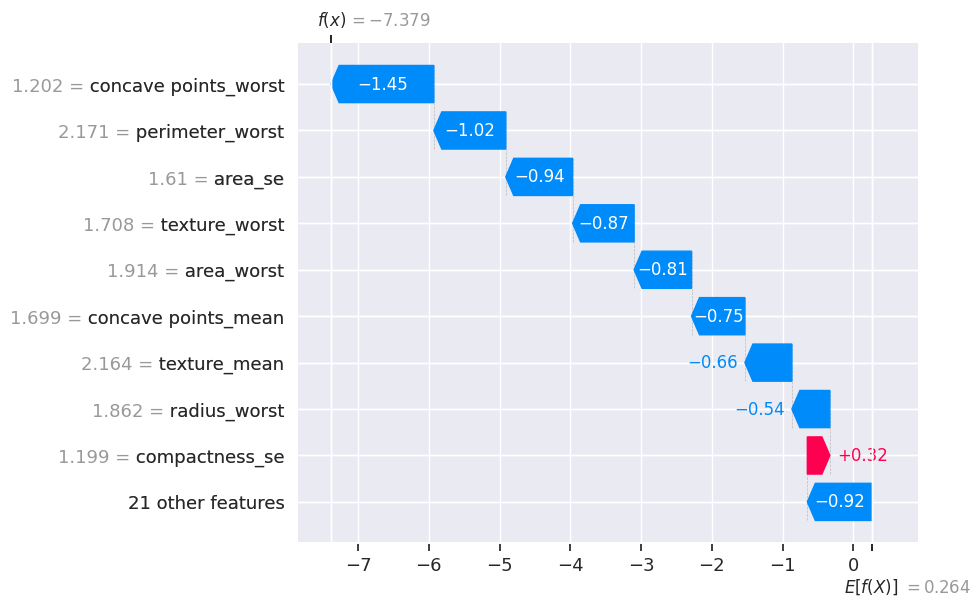

In [42]:
patient_index = 0

print(f"Explaining prediction for Patient Index: {patient_index}")
print(f"Actual Diagnosis: {'Benign (1)' if y_test.iloc[patient_index] == 1 else 'Malignant (0)'}")

patient_data = X_test_scaled_df.iloc[[patient_index]]
predicted_prob = best_xgb_model.predict_proba(patient_data)[0][1]
print(f"Model Predicted Probability of being Benign: {predicted_prob:.4f}")

shap_explanation = explainer(X_test_scaled_df)

plt.figure(figsize=(10, 6))
shap.plots.waterfall(shap_explanation[patient_index])
plt.show()

### **Additional Visualizaton**

Top 5 Most Important Features (SHAP):
             Feature  Mean_Absolute_SHAP
concave points_worst            1.094307
     perimeter_worst            0.881466
       texture_worst            0.873645
             area_se            0.773007
          area_worst            0.768486


/tmp/ipykernel_1369/2816710427.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5_shap, x='Mean_Absolute_SHAP', y='Feature', palette='Blues_r')


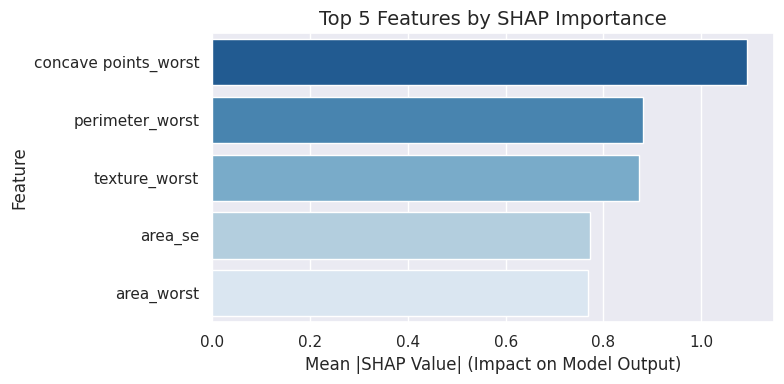

In [43]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)

shap_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Mean_Absolute_SHAP': mean_abs_shap
}).sort_values(by='Mean_Absolute_SHAP', ascending=False)

top_5_shap = shap_importance_df.head(5)
print("Top 5 Most Important Features (SHAP):")
print(top_5_shap.to_string(index=False))

plt.figure(figsize=(8, 4))
sns.barplot(data=top_5_shap, x='Mean_Absolute_SHAP', y='Feature', palette='Blues_r')
plt.title('Top 5 Features by SHAP Importance', fontsize=14)
plt.xlabel('Mean |SHAP Value| (Impact on Model Output)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

<Axes: xlabel='concave points_worst', ylabel='Density'>

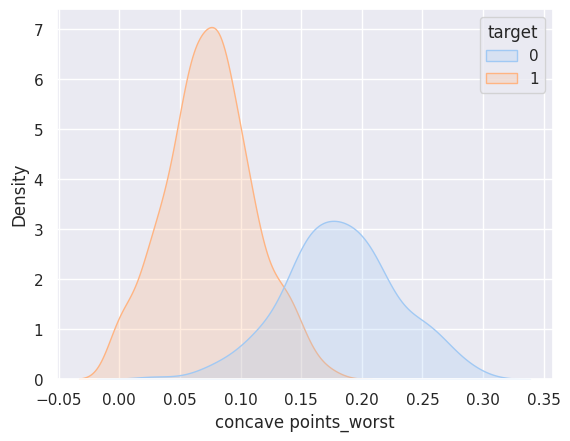

In [45]:
sns.kdeplot(data = df_clean, x = 'concave points_worst', hue = 'target', fill = True)

<Axes: xlabel='perimeter_worst', ylabel='Density'>

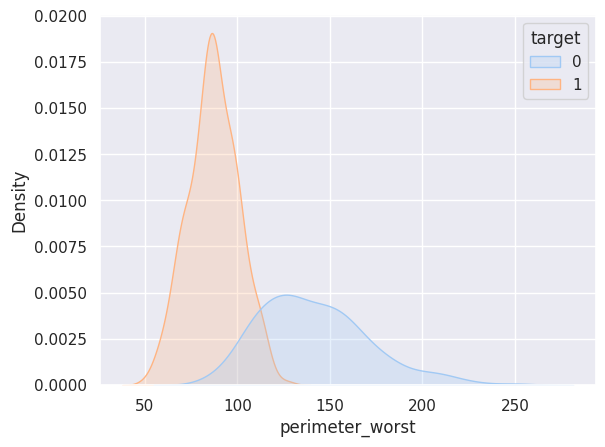

In [46]:
sns.kdeplot(data = df_clean, x = 'perimeter_worst', hue = 'target', fill = True)

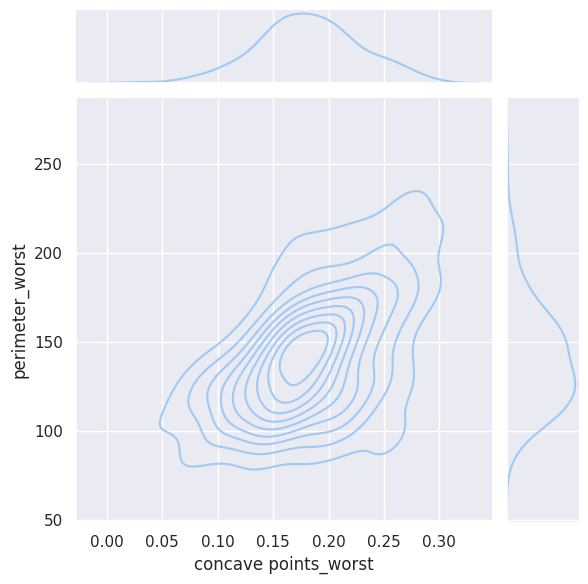

In [48]:
df_malignant = df_clean[df_clean['target'] == 0]
sns.jointplot(x=df_malignant['concave points_worst'], y=df_malignant['perimeter_worst'], kind="kde")

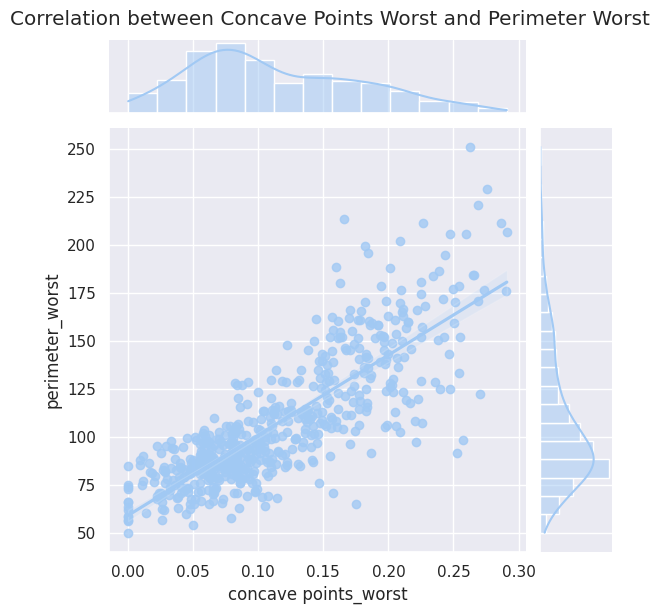

In [49]:
sns.jointplot(x='concave points_worst', y='perimeter_worst', data=df_clean, kind='reg')
plt.suptitle('Correlation between Concave Points Worst and Perimeter Worst', y=1.02)
plt.show()